# Train ConvNeXt-Tiny on Animal-80



In [1]:
import os
from getpass import getpass

token = getpass("Paste your Kaggle API token (KGAT_...): ")
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(token.strip())
os.chmod("/root/.kaggle/access_token", 0o600)
os.environ["KAGGLE_API_TOKEN"] = token.strip()
del token  # don't leave it sitting in a variable

Paste your Kaggle API token (KGAT_...): ··········


## 1. Clone the Repository

In [2]:
!git clone https://github.com/kartikya2522/animal-species-classification-cnn.git
%cd animal-species-classification-cnn

Cloning into 'animal-species-classification-cnn'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 72 (delta 11), reused 56 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 6.11 MiB | 14.59 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/animal-species-classification-cnn


## 2. Install Requirements

In [3]:
!pip install -q -r requirements.txt

## 3. Download the Animal-80 Dataset (same source as the repo/paper)

In [4]:
!kaggle datasets download -d antoreepjana/animals-detection-images-dataset -p data/raw_download --unzip

Dataset URL: https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset
License(s): CC0-1.0
100% 8.92G/8.92G [08:05<00:00, 19.7MB/s]



## 4. Check the Extracted Folder Layout


In [5]:
import os

def show_tree(path, max_depth=2, _depth=0):
    if _depth > max_depth or not os.path.isdir(path):
        return
    for entry in sorted(os.listdir(path))[:10]:
        full = os.path.join(path, entry)
        print("  " * _depth + entry + ("/" if os.path.isdir(full) else ""))
        if os.path.isdir(full):
            show_tree(full, max_depth, _depth + 1)

show_tree("data/raw_download")

test/
  Bear/
    0df78ee76bafd3a9.jpg
    0f899aca6d0fb6e1.jpg
    1cca48c57103a42c.jpg
    1fa809bf6cf5ea36.jpg
    200046eca85cd992.jpg
    23bf858cb1d0ef63.jpg
    23d1d39d81d411da.jpg
    322e901e952ea866.jpg
    3d77555f2ede0b38.jpg
    3df2b6a098712fee.jpg
  Brown bear/
    009ebd2e28a2f9da.jpg
    037ce70dca241ef6.jpg
    040ecb505679fde5.jpg
    0bdada492e85aa0e.jpg
    13e6c2ad1cbc96a5.jpg
    1913a0ece8270f71.jpg
    1f3ecefff4c5fbb6.jpg
    2063cc4372428468.jpg
    2ca16e943e12343d.jpg
    385fea752fdf81bd.jpg
  Bull/
    04d9cced0dd42e6c.jpg
    089cef3acc866627.jpg
    0e2004910f2bf847.jpg
    177351a9b4f0356a.jpg
    1bfd365238e1fedd.jpg
    1f286c4bb30960f5.jpg
    210734f80256d6a4.jpg
    220effd28096ff0f.jpg
    240d2e0a9b4cc7b0.jpg
    249f655af433fc41.jpg
  Butterfly/
    00b34a3601c1398a.jpg
    05d4ff6e4b3031d6.jpg
    0628d98a36cdb01a.jpg
    06507b9821346770.jpg
    0716f55d7debe300.jpg
    07e02444758e34fd.jpg
    08192d5cc57518d3.jpg
    08cf3645808b56b4.jpg
 

## 5. Move the Extracted Folders into Place



In [6]:
import shutil
from pathlib import Path

def find_split_dir(root, split_name):
    root = Path(root)
    for p in root.rglob(split_name):
        if not p.is_dir():
            continue
        for class_dir in p.iterdir():
            if class_dir.is_dir() and (class_dir / "Label").exists():
                return p
    return None

train_src = find_split_dir("data/raw_download", "train") or find_split_dir("data/raw_download", "Train")
test_src = find_split_dir("data/raw_download", "test") or find_split_dir("data/raw_download", "Test")

assert train_src is not None, "Could not auto-detect the train/ folder — check the tree above and set train_src manually."
assert test_src is not None, "Could not auto-detect the test/ folder — check the tree above and set test_src manually."

Path("data/raw").mkdir(parents=True, exist_ok=True)
if not Path("data/raw/train").exists():
    shutil.move(str(train_src), "data/raw/train")
if not Path("data/raw/test").exists():
    shutil.move(str(test_src), "data/raw/test")

print("train:", train_src, "-> data/raw/train")
print("test:", test_src, "-> data/raw/test")

train: data/raw_download/train -> data/raw/train
test: data/raw_download/test -> data/raw/test


## 6. Run the Repo's Existing Preprocessing Pipeline

In [7]:
!python -m src.preprocessing.crop_and_resize
!python -m src.preprocessing.split_dataset
!python -m src.preprocessing.augment

[train] done: Spider (856 source images)
[train] done: Shrimp (30 source images)
[train] done: Rabbit (216 source images)
[train] done: Squirrel (367 source images)
[train] done: Centipede (194 source images)
[train] done: Crab (309 source images)
[train] done: Parrot (421 source images)
[train] done: Polar bear (229 source images)
[train] done: Woodpecker (171 source images)
[train] done: Rhinoceros (214 source images)
[train] done: Raven (62 source images)
[train] done: Raccoon (103 source images)
[train] done: Butterfly (1875 source images)
[train] done: Mouse (151 source images)
[train] done: Cheetah (132 source images)
[train] done: Monkey (770 source images)
[train] done: Zebra (181 source images)
[train] done: Scorpion (80 source images)
[train] done: Kangaroo (98 source images)
[train] done: Eagle (719 source images)
[train] done: Goat (202 source images)
[train] done: Giraffe (298 source images)
[train] done: Snake (562 source images)
[train] done: Whale (287 source images)
[t

## 7. Training Setup (Hyperparameters, Seed, Output Paths)



In [8]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from src.utils import config
from src.utils.dataset import AnimalDataset
from src.utils.metrics import accuracy_score, top_k_accuracy, per_class_accuracy
from src.utils.transforms import get_train_transform, get_eval_transform

SEED = 42
EPOCHS = 12
BATCH_SIZE = 32
LR = 0.0001
WEIGHT_DECAY = 1e-4

# keep everything from this run outside the cloned repo folder
OUTPUT_DIR = Path("/content/convnext_tiny_run")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUT = OUTPUT_DIR / "convnext_tiny_best.pt"
HISTORY_PATH = OUTPUT_DIR / "convnext_tiny_history.csv"
RESULTS_PATH = OUTPUT_DIR / "convnext_tiny_results.json"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 8. Build Datasets & Dataloaders

In [9]:
# manifest.csv paths use backslashes (Windows) - fix for Linux/Mac
df = pd.read_csv(config.MANIFEST_PATH)
df["filepath"] = df["filepath"].str.replace("\\", "/", regex=False)
manifest_path = OUTPUT_DIR / "manifest_fixed.csv"
df.to_csv(manifest_path, index=False)

train_dataset = AnimalDataset(manifest_path, "train", get_train_transform())
val_dataset = AnimalDataset(manifest_path, "val", get_eval_transform())
test_dataset = AnimalDataset(manifest_path, "test", get_eval_transform())

# use the same class order (from train) for val/test so labels line up
val_dataset.classes = train_dataset.classes
val_dataset.class_to_idx = train_dataset.class_to_idx
test_dataset.classes = train_dataset.classes
test_dataset.class_to_idx = train_dataset.class_to_idx

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {num_classes} | Train: {len(train_dataset)} | "
      f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 80 | Train: 26308 | Val: 4232 | Test: 7576


## 9. Build ConvNeXt-Tiny Model

In [10]:
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total | {trainable_params:,} trainable")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

hparams = {
    "model": "convnext_tiny",
    "pretrained": True,
    "num_classes": num_classes,
    "optimizer": "Adam",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": None,
    "loss": "CrossEntropyLoss",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "device": str(device),
}
print("\nHyperparameters:")
for k, v in hparams.items():
    print(f"  {k:<15} = {v}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 183MB/s]


Parameters: 27,881,648 total | 27,881,648 trainable

Hyperparameters:
  model           = convnext_tiny
  pretrained      = True
  num_classes     = 80
  optimizer       = Adam
  lr              = 0.0001
  weight_decay    = 0.0001
  scheduler       = None
  loss            = CrossEntropyLoss
  epochs          = 12
  batch_size      = 32
  seed            = 42
  device          = cuda


## 10. Training Loop


In [11]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_preds.append(logits.argmax(1).detach().cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    n = len(loader.dataset)
    mean_loss = total_loss / n
    acc = accuracy_score(np.concatenate(all_preds), np.concatenate(all_labels))
    return mean_loss, acc


history = []
best_val_acc = -1.0
wall_start = time.time()
epoch_times = []

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, device)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    row = {
        "epoch": epoch,
        "train_loss": round(train_loss, 6),
        "train_acc": round(train_acc, 6),
        "val_loss": round(val_loss, 6),
        "val_acc": round(val_acc, 6),
        "lr": LR,
        "epoch_time": round(epoch_time, 2),
    }
    history.append(row)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
            "hparams": hparams,
        }, MODEL_OUT)
        marker = "  <- saved"
    else:
        marker = ""

    print(f"Epoch {epoch:>2}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {epoch_time:.1f}s{marker}")

wall_total = time.time() - wall_start
avg_epoch_time = float(np.mean(epoch_times))
print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f} | "
      f"Total time: {wall_total:.1f}s | Avg epoch: {avg_epoch_time:.1f}s")

Epoch  1/12 | train_loss=0.8621 train_acc=0.7974 | val_loss=0.3329 val_acc=0.8854 | 591.4s  <- saved
Epoch  2/12 | train_loss=0.2474 train_acc=0.9166 | val_loss=0.3470 val_acc=0.8828 | 561.5s
Epoch  3/12 | train_loss=0.1804 train_acc=0.9348 | val_loss=0.3415 val_acc=0.8802 | 561.8s
Epoch  4/12 | train_loss=0.1574 train_acc=0.9411 | val_loss=0.3833 val_acc=0.8783 | 561.9s
Epoch  5/12 | train_loss=0.1404 train_acc=0.9465 | val_loss=0.3582 val_acc=0.8871 | 561.5s  <- saved
Epoch  6/12 | train_loss=0.1299 train_acc=0.9485 | val_loss=0.4057 val_acc=0.8733 | 561.1s
Epoch  7/12 | train_loss=0.1214 train_acc=0.9523 | val_loss=0.3828 val_acc=0.8795 | 561.0s
Epoch  8/12 | train_loss=0.1161 train_acc=0.9547 | val_loss=0.4054 val_acc=0.8736 | 561.1s
Epoch  9/12 | train_loss=0.1014 train_acc=0.9589 | val_loss=0.4298 val_acc=0.8752 | 560.8s
Epoch 10/12 | train_loss=0.1057 train_acc=0.9577 | val_loss=0.4194 val_acc=0.8738 | 560.5s
Epoch 11/12 | train_loss=0.1105 train_acc=0.9564 | val_loss=0.4277 val

## 11. Save Training History (CSV)

In [12]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
print(f"Saved training history -> {HISTORY_PATH}")
history_df

Saved training history -> /content/convnext_tiny_run/convnext_tiny_history.csv


,epoch,train_loss,train_acc,val_loss,val_acc,lr,epoch_time
0,1,0.862086,0.797438,0.332867,0.885397,0.0001,591.43
1,2,0.247400,0.916603,0.346963,0.882798,0.0001,561.48
2,3,0.180447,0.934849,0.341450,0.880198,0.0001,561.79
3,4,0.157374,0.941121,0.383326,0.878308,0.0001,561.94
4,5,0.140367,0.946480,0.358185,0.887051,0.0001,561.54
5,6,0.129924,0.948495,0.405670,0.873346,0.0001,561.09
6,7,0.121371,0.952334,0.382835,0.879490,0.0001,561.02
7,8,0.116120,0.954691,0.405425,0.873582,0.0001,561.12
8,9,0.101362,0.958872,0.429775,0.875236,0.0001,560.79
9,10,0.105741,0.957693,0.419385,0.873819,0.0001,560.53


## 12. Plot Training Curves (Loss & Accuracy)

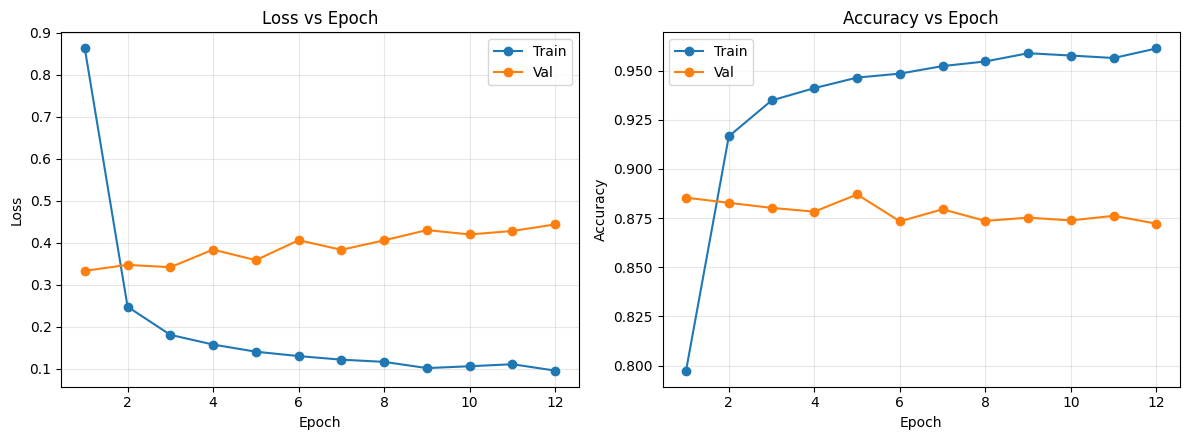

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_curves.png", dpi=150)
plt.show()

## 13. Evaluate on Test Set

Loads the best checkpoint (by val accuracy) and computes test accuracy, top-5 accuracy,
macro-average accuracy, and per-class accuracy — using the repo's own `src.utils.metrics`
so these numbers are computed identically to the ResNet50 baseline's.

In [23]:
ckpt = torch.load(MODEL_OUT, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f})")

model.eval()
all_logits, all_preds, all_labels = [], [], []
test_start = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu().numpy())
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(labels.numpy())
test_time = time.time() - test_start

all_logits = np.concatenate(all_logits)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

test_accuracy = accuracy_score(all_preds, all_labels)
test_top5_accuracy = top_k_accuracy(all_logits, all_labels, k=5)
pc = per_class_accuracy(all_preds, all_labels, num_classes=num_classes, class_names=class_names)
macro_avg_accuracy = pc["macro_avg"]
per_class_acc = pc["per_class"]

print(f"Test accuracy     : {test_accuracy:.4f}")
print(f"Test eval time    : {test_time:.1f}s")

Loaded best checkpoint (epoch 5, val_acc=0.8871)
Test accuracy     : 0.8152
Test eval time    : 51.4s


# Cell 14. Precision, Recall & F1-Score

In [25]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    all_labels, all_preds, labels=range(num_classes), zero_division=0
)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Precision (macro)    : {precision_macro:.4f}")
print(f"Recall    (macro)    : {recall_macro:.4f}")
print(f"F1-score  (macro)    : {f1_macro:.4f}")
print(f"Precision (weighted) : {precision_weighted:.4f}")
print(f"Recall    (weighted) : {recall_weighted:.4f}")
print(f"F1-score  (weighted) : {f1_weighted:.4f}")

per_class_prf1_df = pd.DataFrame({
    "class": class_names, "precision": precision_per_class,
    "recall": recall_per_class, "f1_score": f1_per_class, "support": support_per_class,
})
per_class_prf1_df.to_csv(OUTPUT_DIR / "convnext_tiny_precision_recall_f1.csv", index=False)

report_text = classification_report(all_labels, all_preds, target_names=class_names, digits=3, zero_division=0)
(OUTPUT_DIR / "convnext_tiny_classification_report.txt").write_text(report_text)
print(report_text)

Precision (macro)    : 0.7681
Recall    (macro)    : 0.7595
F1-score  (macro)    : 0.7403
Precision (weighted) : 0.8260
Recall    (weighted) : 0.8152
F1-score  (weighted) : 0.8046
                       precision    recall  f1-score   support

                 Bear      0.828     0.571     0.676        42
           Brown bear      0.921     0.795     0.854        44
                 Bull      0.472     0.549     0.508        91
            Butterfly      0.940     0.935     0.938       185
                Camel      0.944     0.895     0.919        38
               Canary      0.692     0.500     0.581        18
          Caterpillar      0.824     0.847     0.836        72
               Cattle      0.805     0.493     0.611       209
            Centipede      0.762     0.582     0.660        55
              Cheetah      0.489     0.564     0.524        39
              Chicken      0.921     0.910     0.915       166
                 Crab      0.718     0.975     0.827       120


## 15. Confusion Matrix (Test Set)

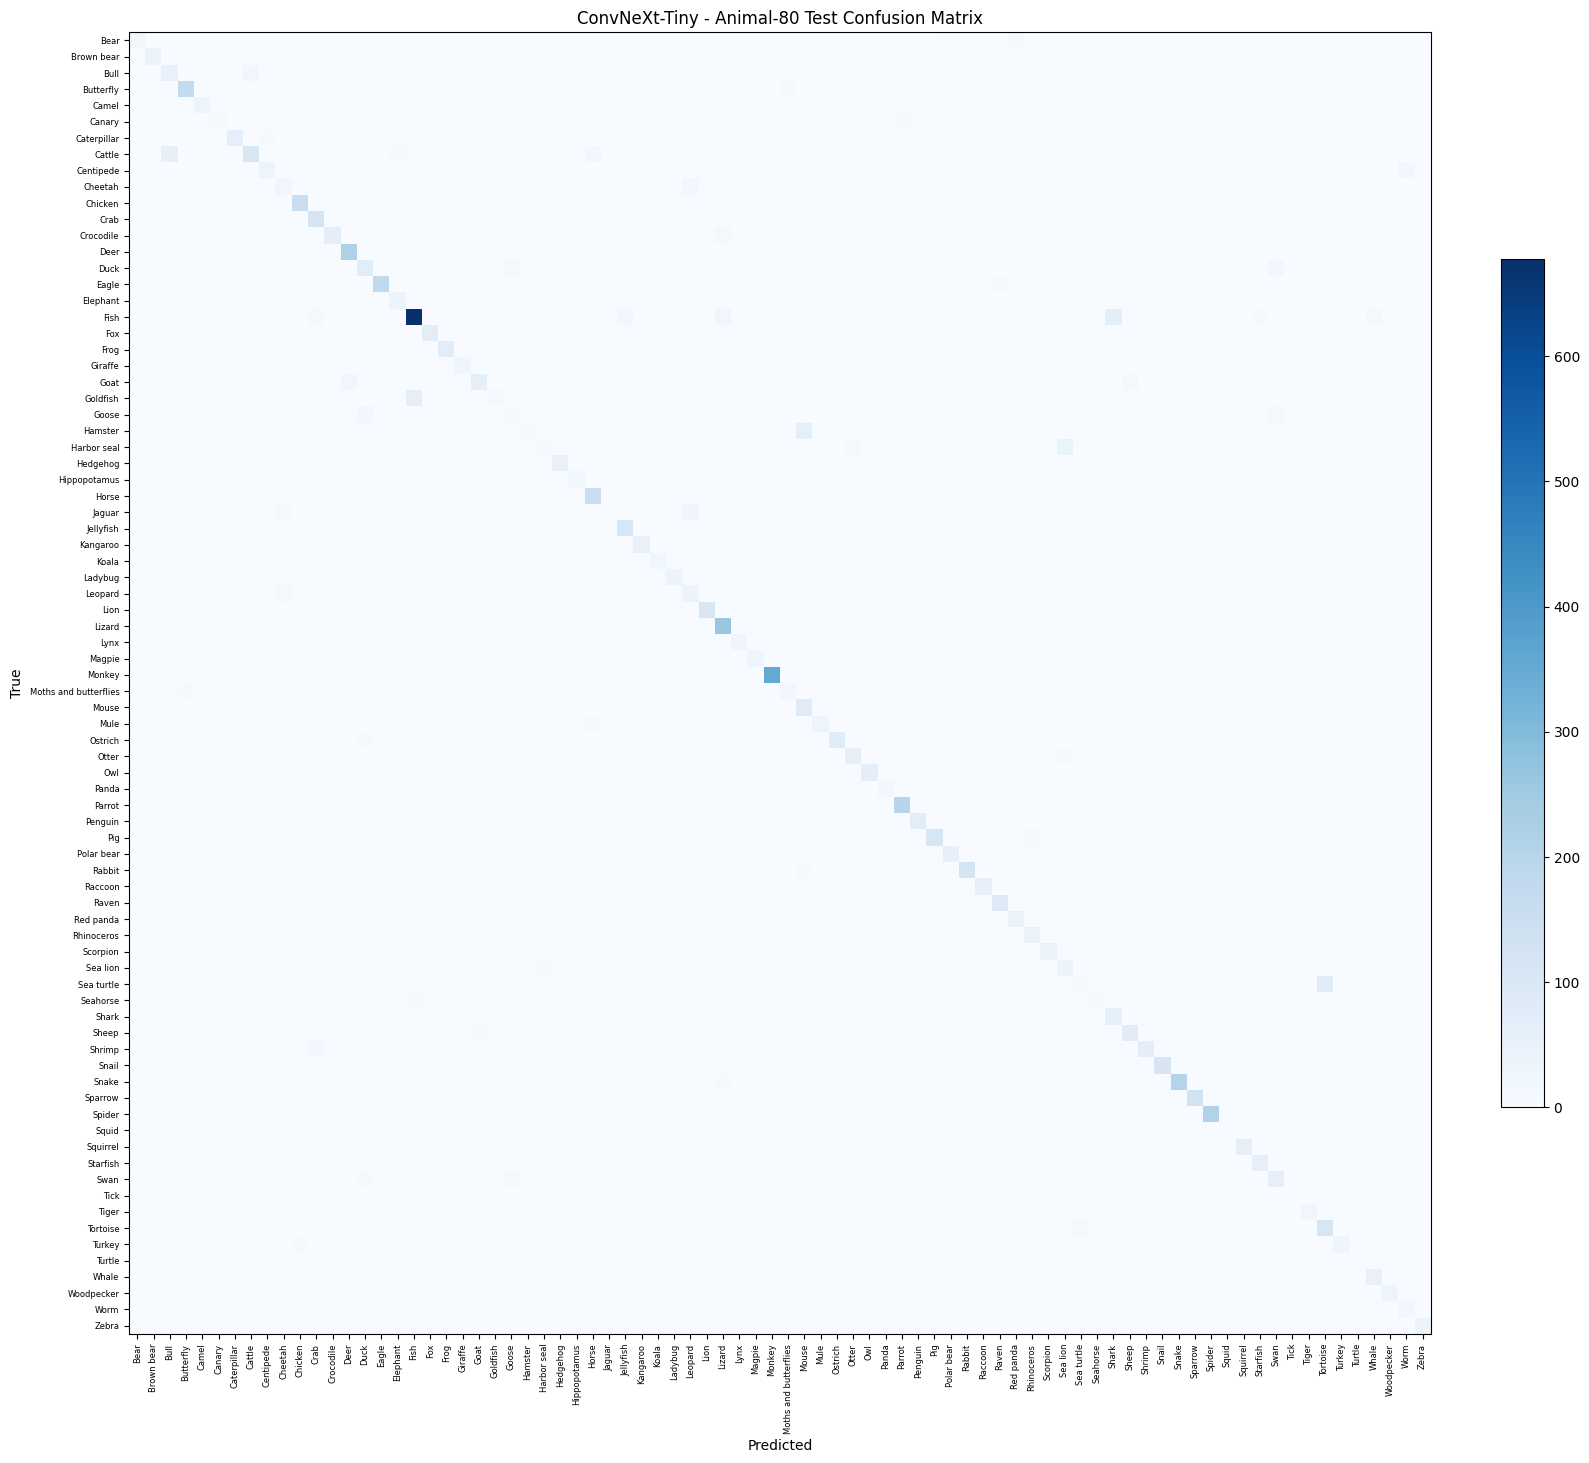

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(16, 16))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=90, fontsize=6)
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names, fontsize=6)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("ConvNeXt-Tiny - Animal-80 Test Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 16. Per-Class Accuracy Bar Chart

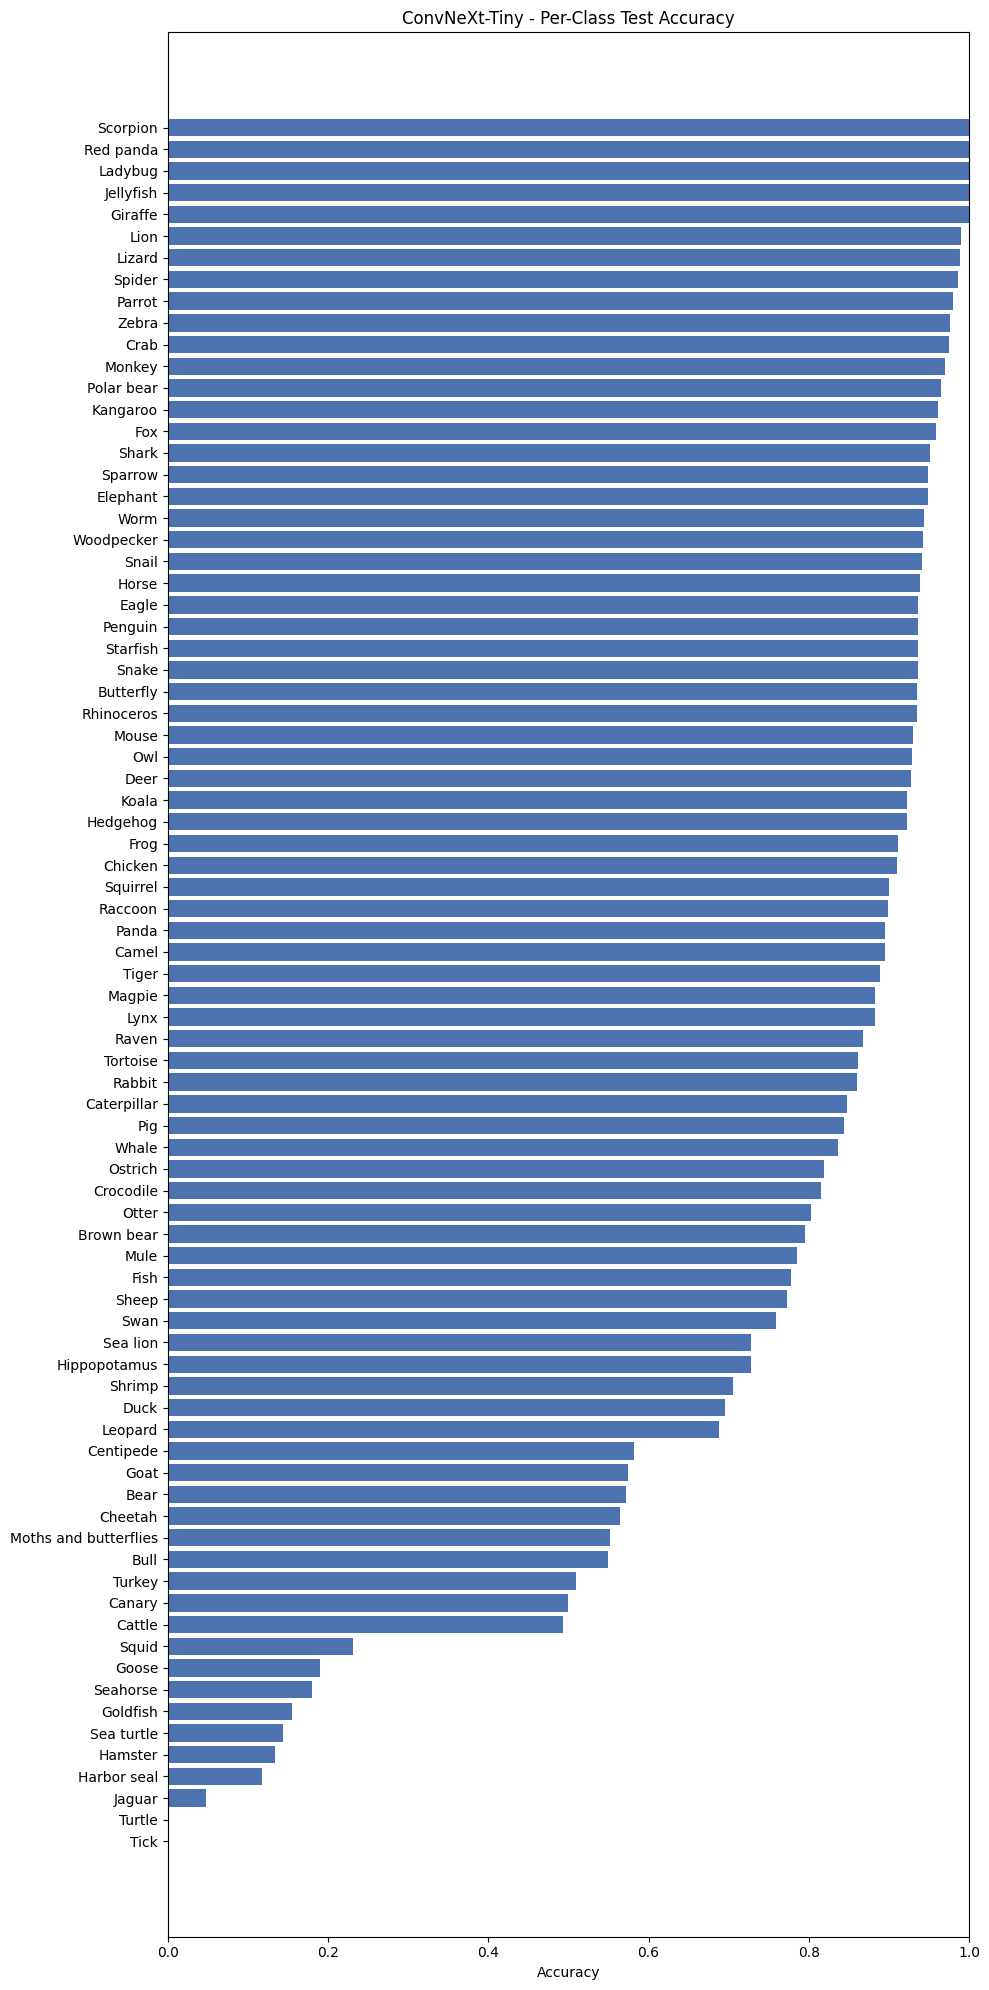

In [27]:
sorted_items = sorted(per_class_acc.items(), key=lambda x: (x[1] is None, x[1]))
names_sorted = [k for k, v in sorted_items]
accs_sorted = [v if v is not None else 0 for k, v in sorted_items]

fig, ax = plt.subplots(figsize=(10, 20))
ax.barh(names_sorted, accs_sorted, color="#4C72B0")
ax.set_xlabel("Accuracy")
ax.set_title("ConvNeXt-Tiny - Per-Class Test Accuracy")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_class_accuracy.png", dpi=150)
plt.show()

## 17. Save Final Results (JSON)

Same structure as the repo's `outputs/resnet50_results.json`, so the two can be diffed/compared directly.

In [29]:
results = {
    "hparams": hparams,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "best_val_accuracy": best_val_acc,
    "total_train_time_s": round(wall_total, 2),
    "avg_epoch_time_s": round(avg_epoch_time, 2),
    "test_eval_time_s": round(test_time, 2),
    "test_accuracy": test_accuracy,
    "per_class_accuracy": per_class_acc,
}

with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved results -> {RESULTS_PATH}")

Saved results -> /content/convnext_tiny_run/convnext_tiny_results.json


## 18. Results Summary

In [30]:
print("=" * 50)
print("CONVNEXT-TINY — ANIMAL-80 — FINAL RESULTS")
print("=" * 50)
print(f"Best Val Accuracy   : {best_val_acc:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Total Train Time    : {wall_total:.1f}s ({wall_total/60:.1f} min)")
print(f"Avg Epoch Time      : {avg_epoch_time:.1f}s")
print("=" * 50)

CONVNEXT-TINY — ANIMAL-80 — FINAL RESULTS
Best Val Accuracy   : 0.8871
Test Accuracy       : 0.8152
Total Train Time    : 6764.3s (112.7 min)
Avg Epoch Time      : 563.7s


## 19. Download All Outputs

Zips `convnext_tiny_best.pt`, `convnext_tiny_history.csv`, `convnext_tiny_results.json`,
and `figures/` (training curves, confusion matrix, per-class chart) into one archive.

In [31]:
import shutil
from google.colab import files

zip_path = shutil.make_archive("/content/convnext_tiny_run", "zip", OUTPUT_DIR)
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>